Initialize the SBI task


In [1]:
!pip install git+"https://github.com/nidropakshin2/Sequential-FMPE.git#egg=sfmpe&subdirectory=code"
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

  Cloning https://github.com/nidropakshin2/Sequential-FMPE.git to /tmp/pip-install-x3y99cdp/sfmpe_109599d9e50145e8830d0733a92635c3
  Running command git clone --filter=blob:none --quiet https://github.com/nidropakshin2/Sequential-FMPE.git /tmp/pip-install-x3y99cdp/sfmpe_109599d9e50145e8830d0733a92635c3
  Resolved https://github.com/nidropakshin2/Sequential-FMPE.git to commit b7c2874ec0f39eaa474f2e798a8dba5d0f6b1e41
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for sfmpe: filename=sfmpe-0.1.0-py3-none-any.whl size=37638 sha256=34d18973f5a0f10697f1fa242e3bf72c73ab5bab36bd781a647b4c5545f8c5e5
  Stored in directory: /tmp/pip-ephem-wheel-cache-w6lnrsss/wheels/c3/bf/ce/2cc28442a8cc903c0b14c96e16a1d61339868937fd26cbddc9
Successfully built sfmpe
Looking in indexes: https://download.pytorch.org/whl/cu126


In [2]:
config = {
    "prior":
        {
        "gamma_range": [0.05, 0.5],
        "beta_range": [0.5, 5.0],
        },
    "simulator":
        {
        "S": 1000, #[1500, 2000], # int, tuple, number of Susceptible individuals or bounds for following uniform distribution
        "I": 100, #[150, 200], # int, tuple, number of Infectious individuals or bounds for following uniform distribution
        "R": 50, #[0, 50], # int, tuple, number of Recovered individuals or bounds for following uniform distribution
        "T": 100, #[100, 120],  # int, tuple, simulation duration in days or bounds for following uniform distribution
        },
    "summary": 
        {
        "type": "handmade",
        "input_dim": 3,
        "hidden_dim": 32,
        "num_layers": 2,
        "output_dim": 5,
        "dropout": 0.1,
        },
    "logger":
        {
        "name": "SIR",
        "level": "DEBUG",
        "log_file_path": "logs/sir.log",
        }
}
import os

if not os.path.exists("./logs"):
    os.mkdir("./logs")
if not os.path.exists("./models"):
    os.mkdir("./models")

In [3]:
import yaml
import torch
import time
import matplotlib.pyplot as plt


from sfmpe.tasks.SIR import SIRTask


# config_path = './configs/sir_config.yaml'
# with open(config_path) as f:
#     config = yaml.safe_load(f)
device = 'cuda'
task = SIRTask(config, device)
task.summary.to(device)
logger = task.logger
logger.info("Starting SIR task")

2026-09-05 10:27:30,385 - SIR - INFO - Starting SIR task


In [4]:
from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal(dim=task.theta_dim)
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim, num_layers=5)
path = AffinePath()
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

# optimizer = torch.optim.Adam(flow_model.velocity_model.parameters(), lr=1e-4)
optimizer = torch.optim.Adam([
                        # {"params": task.summary.parameters(), "lr":1e-4},
                        {"params": flow_model.parameters(), "lr":1e-4}
                        ])
loss_fn = torch.nn.MSELoss()

def preprocessor(theta, x):
    s = task.simulate(theta).to(device)
    x = task.summarize(s).to(device)
    return theta, x

flow_model.to(device)
fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn)#, dataset_prepocessor=preprocessor)
logger.info("Initialized flow matching estimator")

2026-09-05 10:27:34,066 - SIR - INFO - Initialized flow model
2026-09-05 10:27:37,144 - SIR - INFO - Initialized flow matching estimator


In [5]:
from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

theta_0, x_0 = task.simulate_dataset((20,))
# theta_0 = torch.tensor([[1.6667, 0.4016]]).to(device)
# theta_0 = torch.tensor([[1.2621, 0.4558]]).to(device) 
# x_0 = task.summarize(task.simulate(theta_0))
# theta_0, x_0 = theta_0.expand(5, -1), x_0.expand(5, -1)
task.logger.info(f"Starting SFMPE for theta {theta_0}")

params = ProposalParams()
params.task = task
params.method = "Truncated"
params.theta_0 = theta_0
params.x_0 = x_0
params.method_params = {'scale': 0.8, 'quantile': 0.5}


2026-09-05 10:27:38,869 - SIR - INFO - Starting SFMPE for theta tensor([[0.5342, 0.1163],
        [0.3682, 0.1870],
        [0.7421, 0.4621],
        [1.2637, 0.4181],
        [0.3551, 0.1118],
        [0.2659, 0.1636],
        [0.1102, 0.1217],
        [0.1813, 0.1548],
        [1.0590, 0.2537],
        [0.1680, 0.2157],
        [0.1162, 0.1006],
        [0.0798, 0.0712],
        [0.1768, 0.3149],
        [0.0625, 0.0831],
        [0.3384, 0.3854],
        [0.0399, 0.0698],
        [0.2856, 0.0938],
        [0.4371, 0.2195],
        [0.3329, 0.1896],
        [0.6705, 0.2615]], device='cuda:0')


In [6]:
# theta = task.prior.sample((1,)).to(device)
# s = task.summarize(task.simulate(theta.expand(1000, *theta.shape)))
# print(theta)
# s.max(dim=0)[0], s.mean(dim=0), s.min(dim=0)[0], s.std(dim=0)

In [7]:
# from sbi.inference import SMCABC

# smc = SMCABC(simulator=lambda theta: task.summary(task.simulator.simulate(theta)),
#              prior=task.prior)
# output = smc(x_0, 
#     num_particles=1000,
#     num_initial_pop=5000,
#     num_simulations=5000,
#     epsilon_decay=0.1)
# plt.scatter(torch.log(output[:, 0]), torch.log(output[:, 1]), s=1)
# plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]))

2026-09-05 10:27:38,941 - SIR - DEBUG - tensor([[ 0.9146, -1.0540, -1.1058, -1.4084,  1.3167],
        [ 0.3499, -0.7846, -1.0451, -1.1097,  0.9741],
        [ 0.3397, -0.6733, -1.0469, -1.1139,  0.9618],
        [ 0.7437, -0.8338, -1.0940, -1.3113,  1.1656],
        [ 0.6013, -0.9602, -1.0252, -1.3806,  1.3356],
        [ 0.1898, -0.6811, -1.0664, -0.9250,  0.7466],
        [ 0.1811, -0.8290, -1.2739, -0.2239, -0.2354],
        [ 0.1603, -0.7926, -1.1627, -0.5643,  0.2434],
        [ 0.8907, -0.9575, -1.1149, -1.3603,  1.2194],
        [ 0.1843, -0.8710, -1.2831, -0.1870, -0.3002],
        [ 0.0590, -0.9516, -1.1437, -0.4597,  0.1199],
        [ 0.0639, -1.0345, -1.1180, -0.4957,  0.1892],
        [ 0.2015, -0.8905, -1.3406, -0.0197, -0.5409],
        [ 0.2018, -0.8787, -1.3214, -0.0941, -0.4181],
        [ 0.1819, -0.7925, -1.2549, -0.2927, -0.1556],
        [ 0.2121, -0.9152, -1.3478, -0.0061, -0.5453],
        [ 0.5860, -0.9994, -1.0193, -1.3693,  1.3398],
        [ 0.2977, -0.7281

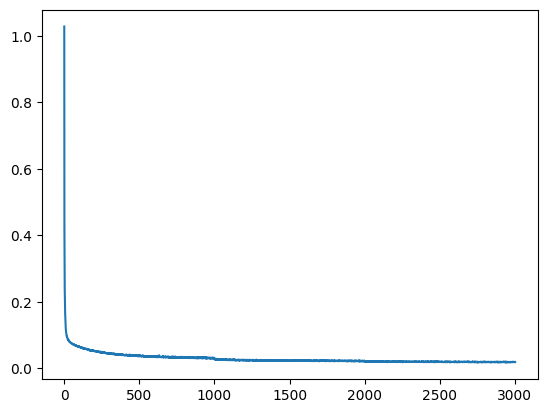

In [8]:
datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SIR_{datetime}.pth.tar.gz"

num_rounds = 3
sims_per_round = 10000
sims_per_sample = 1
epochs = 1000
show_every = epochs // 10 

train = True

manager = RoundManager(task, fm_estimator, params,
                       device=device,
                    #    storage_dir=f"./datasets/SIR_{datetime}"
                       )

if train:
   manager.run_sequential(num_rounds=num_rounds,
                        sims_per_round=sims_per_round,
                        sims_per_sample=sims_per_sample,
                        path=path, epochs=epochs, 
                        show_every=show_every,
                        clean_sampling=True, device=device,
                        batch_size=1000, shuffle=True,)
   loss = manager.losses
   _, ax = plt.subplots()
   ax.plot(loss)
else:
   manager.load_model("./models/SIR_2026-09-04_10_09_55.pth.zip")

In [9]:
sim_store = manager.store
# log_plot = False

# _, ax = plt.subplots(num_rounds, 1, sharex=True, figsize=(3, 3 * num_rounds))
# for r in range(num_rounds):
#     theta, x = sim_store.theta[r], sim_store.x[r]
#     if log_plot:
#         ax[r].scatter(torch.log(theta[:, :, 0]), torch.log(theta[:, :, 1]), s=1/(r+1), alpha=(r+1) / 10)
#         ax[r].scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]), s=10, color="black")
#         ax[r].set_xlim((-4, 2))
#         ax[r].set_ylim((-3.1, -0.5))
#     else:
#         ax[r].scatter(theta[:, :, 0], theta[:, :, 1], s=1/(r+1), alpha=(r+1) / 10)
#         ax[r].scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
#         ax[r].set_xlim(0, 2.5)
#         ax[r].set_ylim(0, 0.5)

In [10]:
# posterior = manager.build_posterior()
# theta_pred = posterior.sample(size=(1000,))
# # i = 1
# if log_plot:
#     plt.scatter(torch.log(theta_pred[:, :, 0]), torch.log(theta_pred[:, :, 1]), s=1)
#     plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]), s=10, color="black")
#     plt.xlim((-4, 1))
#     plt.ylim((-3, -1))
# else:
#     plt.scatter(theta_pred[:, :, 0], theta_pred[:, :, 1], s=1)
#     plt.scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
#     plt.xlim(0, 2.5)
#     plt.ylim(0, 0.5)

# theta_0, theta_pred.mean(dim=0), theta_pred.std(dim=0) 

2026-09-05 12:05:49,011 - SIR - DEBUG - tensor([[ 0.9093, -1.0350, -1.1078, -1.4028,  1.3092],
        [ 0.3550, -0.7765, -1.0213, -1.1916,  1.0899],
        [ 0.3235, -0.6545, -1.0515, -1.0906,  0.9325],
        [ 0.6977, -0.8028, -1.0818, -1.3144,  1.1789],
        [ 0.6339, -0.9409, -1.0467, -1.3533,  1.2916],
        [ 0.1287, -0.7508, -1.0178, -0.9884,  0.8437],
        [ 0.1719, -0.8240, -1.2573, -0.2672, -0.1730],
        [ 0.1533, -0.7165, -1.2119, -0.4313,  0.0566],
        [ 0.9502, -0.9901, -1.1248, -1.3770,  1.2313],
        [ 0.1857, -0.8332, -1.2981, -0.1561, -0.3426],
        [ 0.0687, -0.9569, -1.0953, -0.6178,  0.3481],
        [ 0.1438, -0.8812, -1.1656, -0.4406,  0.1049],
        [ 0.2011, -0.8886, -1.3388, -0.0261, -0.5311],
        [ 0.2046, -0.8883, -1.3278, -0.0562, -0.4740],
        [ 0.1764, -0.8319, -1.2873, -0.1753, -0.3199],
        [ 0.2112, -0.9095, -1.3416, -0.0289, -0.5093],
        [ 0.5753, -0.9720, -1.0194, -1.3757,  1.3461],
        [ 0.3979, -0.7446

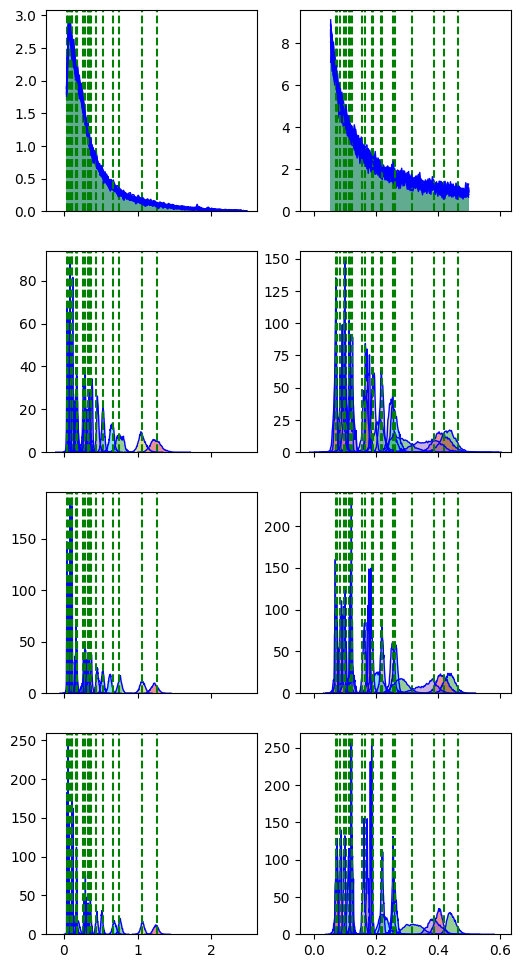

In [11]:
from sfmpe.utils.plotting import dist_plot

sim_store = manager.store
posterior = manager.build_posterior()

dist_plot(
                sim_store.theta[0].detach().cpu(), 
                sim_store.theta[1].detach().cpu(),
                sim_store.theta[2].detach().cpu(),  
                posterior.sample((10000,)).detach().cpu(),
                # manager.clean_sample((1000, )),
                true_param=theta_0.detach().cpu())

In [12]:
pred = posterior.sample((10000,))
print(theta_0, pred.mean(dim=0), pred.std(dim=0))
print(abs(theta_0 - pred.mean(dim=0)).mean(dim=0), pred.std(dim=0).mean(dim=0))


def dist_plot2(*dists, true_param=None, pred_param=None):
        # assert len(dist1.shape) == len(dist2.shape) and dist1.shape[-1] == dist2.shape[-1]
        theta_dim = dists[0].shape[-1]
        num_bins  = [int(dists[i].shape[0] ** 0.5) for i in range(len(dists))]
        
        _, ax = plt.subplots(len(dists), theta_dim, sharex='col', figsize=(3*theta_dim, 3*len(dists)))
        if len(dists) == 1:
            ax = [ax]
        for j in range(theta_dim):
            for thetas, i in zip(dists, range(len(dists))):
                counts, bins, patches = ax[i][j].hist(thetas[:, :, j], bins=num_bins[i], alpha=0.5, density=True)

                bin_centers = (bins[:-1] + bins[1:]) / 2

                ax[i][j].plot(bin_centers, counts, 'b-', linewidth=1)

                if true_param is not None:
                    ax[i][j].axvline(x=true_param[:, j], linestyle='--', color='green')
                
                if pred_param is not None:
                    ax[i][j].axvline(x=pred_param[:, j], linestyle='--', color='red')

# dist_plot2(pred, true_param=theta_0, pred_param=pred.mean(dim=0))

tensor([[0.5342, 0.1163],
        [0.3682, 0.1870],
        [0.7421, 0.4621],
        [1.2637, 0.4181],
        [0.3551, 0.1118],
        [0.2659, 0.1636],
        [0.1102, 0.1217],
        [0.1813, 0.1548],
        [1.0590, 0.2537],
        [0.1680, 0.2157],
        [0.1162, 0.1006],
        [0.0798, 0.0712],
        [0.1768, 0.3149],
        [0.0625, 0.0831],
        [0.3384, 0.3854],
        [0.0399, 0.0698],
        [0.2856, 0.0938],
        [0.4371, 0.2195],
        [0.3329, 0.1896],
        [0.6705, 0.2615]], device='cuda:0') tensor([[0.5168, 0.1205],
        [0.3621, 0.1820],
        [0.7648, 0.4430],
        [1.2483, 0.4020],
        [0.3318, 0.1194],
        [0.2777, 0.1711],
        [0.1231, 0.1213],
        [0.1709, 0.1594],
        [1.0664, 0.2539],
        [0.1743, 0.2244],
        [0.1100, 0.1081],
        [0.0742, 0.0708],
        [0.1918, 0.3197],
        [0.0595, 0.0849],
        [0.3200, 0.3873],
        [0.0425, 0.0721],
        [0.2945, 0.0962],
        [0.4459, 0.2

In [13]:
# tensor([[0.2387, 0.0550],
#         [1.2621, 0.4558],
#         [0.0839, 0.0572],
#         [0.0906, 0.0638],
#         [0.1031, 0.0583],
#         [0.4003, 0.2856],
#         [1.1808, 0.3677],
#         [0.2910, 0.1566],
#         [1.1429, 0.4723],
#         [0.7993, 0.4970]]) tensor([[0.2946, 0.0723],
#         [1.4920, 0.5129],
#         [0.1195, 0.0786],
#         [0.1079, 0.1005],
#         [0.1444, 0.0744],
#         [0.4904, 0.3817],
#         [1.4859, 0.4770],
#         [0.4050, 0.2104],
#         [1.3361, 0.5179],
#         [0.8700, 0.5225]]) tensor([[0.0102, 0.0170],
#         [0.0403, 0.0173],
#         [0.0121, 0.0086],
#         [0.0062, 0.0044],
#         [0.0095, 0.0054],
#         [0.0276, 0.0190],
#         [0.0399, 0.0176],
#         [0.0147, 0.0100],
#         [0.0594, 0.0146],
#         [0.0238, 0.0194]])

In [14]:
# log_probs = posterior.log_prob(theta_pred)

In [15]:
# plt.scatter(theta_pred[..., 1], log_probs, c=log_probs)

In [16]:
# exp = torch.exp(log_probs)
# plt.scatter(theta_pred[..., 1], exp, c=exp)
# plt.ylim(0, 10000)

In [17]:
# samples = flow_model.init_dist.sample((10000,)) 
# logs = flow_model.init_dist.log_prob(samples)
# exp = torch.exp(logs)
# plt.scatter(samples[..., 0], exp, c=exp)

In [18]:
# log_probs = posterior.log_prob(theta_pred)

# torch.quantile(log_probs, 0.15)
# baselogp, logp_corr = log_probs
# logp_pred = baselogp + logp_corr[-1]

In [19]:
# mask = torch.where(log_probs <= torch.quantile(log_probs, 0.5))
# plt.scatter(theta_pred[mask][:, 0], theta_pred[mask][:, 1], s=1)
# plt.scatter(theta_0[:, 0], theta_0[:, 1], color="black", s=10)
# plt.xlim(0, 2.5)
# plt.ylim(0, 0.5)

In [20]:
# from sfmpe.data.round_dataset import RoundDataset
# from sfmpe.data.simulation_store import SimulationStore


# init_dist = Uniform()
# v_model = SimpleVelocityField(task.theta_dim, task.data_dim, hidden_dim=64)
# path = AffinePath()
# flow = FlowModel(v_model, init_dist, path)

# optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
# loss_fn = torch.nn.MSELoss()

# def preprocessor(theta, x, *args):
#     std_theta = torch.log(theta).std(dim=-1)
#     std_x     = x.std(dim=-1)
#     alpha_theta = 0.1
#     alpha_x     = 0.1
#     return torch.exp(torch.log(theta) + alpha_theta * std_theta * torch.randn_like(theta)), \
#                x + alpha_x * std_x * torch.randn_like(x)


# fm_estim = FlowMatchingEstimator(flow, optimizer, loss_fn, dataset_prepocessor=preprocessor)


# store = SimulationStore()
# theta, x = task.simulate_dataset((10000, ))
# store.add(theta, x, 0)
# dataset = RoundDataset(store, [0])

In [21]:
# loss = fm_estim.train(dataset, epochs=2000, show_every=200)
# posterior = fm_estim.build_posterior()
# # plt.scatter(theta_0[:, 0], theta_0[:, 1], s=1)

In [22]:
# theta, x = dataset.theta, dataset.x
# theta_1, x = preprocessor(theta, x)
# # theta_1 = torch.exp(torch.log(theta) + 0.1*torch.randn_like(theta))
# plt.scatter(torch.log(theta_1[:, 0]), torch.log(theta_1[:, 1]), s=1)

# theta.std(dim=0) * torch.randn_like(theta)

In [23]:
# import corner

# for i in range(theta_pred.shape[1]):
#     samples = theta_pred[:, i, :].numpy()
#     fig = corner.corner(samples, bins=40, levels=[0.5], labels=['beta', 'gamma'],
#                         plot_datapoints=False, plot_contours=True, smooth=1)

In [24]:
# def sbc(manager):
#     thetas_prior = manager.task.prior.sample((1000,))
#     num_samples = 1000
#     samples = manager.proposal.sample((num_samples, 1000,))
#     print(samples.shape, thetas_prior[:, None, None, :].shape)
#     ranks = (samples < thetas_prior[:, None, None, :]).sum(dim=-1)
#     print(ranks.shape)
#     return ranks


# ranks = sbc(manager)
# _, ax = plt.subplots(1, 2, figsize=(8, 2.5))
# ax[0].hist(ranks[:, 0].cpu(), bins=20, color="#8000ff")
# ax[1].hist(ranks[:, 1].cpu(), bins=20, color="orange")
